<a href="https://colab.research.google.com/github/ranjanchoubey/FedArtML/blob/main/examples/13_Get_started_create_FL_data_label_skew_dirichlet_EdgeIIoTset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Getting started with FedArtML creating FL data (label skew) and implementing an FL model

Our ***FedArTML*** tool facilitates the generation of non-IID datasets
in a controlled way to support federated learning (FL) research for federated datasets from centralized datasets. It includes classes and functions to create federated datasets from centralized data, given the **number** of **clients** and the degree of heterogeneity (**non-IID-ness**) desired.

This guide aims to **understand** using the **SplitAsFederatedData** class to create federated datasets with the **Dirichlet method** for **Label skew**. We use the `Edge-IIoTset` dataset for our tests. Moreover, we include the `Flower framework` to train an FL model using the output from the FedArtML library.

This notebook implements the **DeepFed** CNN-GRU architecture from *Li et al., IEEE Transactions on Industrial Informatics, 2021*.

**Notes:**
1. To check the source code, you can visit the [GitHub repo](https://github.com/Sapienza-University-Rome/FedArtML)
2. To check the documentation, you visit the [dedicated link](https://fedartml.readthedocs.io/en/latest/)

# Install libraries

First, installing the FedArtML and Flower libraries from Pypi (the latest version) is necessary.

In [ ]:
#@title Install Dependencies { display-mode: "form" }
!pip install -q fedartml flwr[simulation] jax jaxlib keras

# Import libraries

In [ ]:
#@title Import Libraries & Configure Environment { display-mode: "form" }

import os
os.environ["KERAS_BACKEND"] = "jax"
# Force all JAX/Keras work onto the NVIDIA GPU. Pre-allocation is disabled to
# avoid cuSolver handle exhaustion when Flower spawns many short-lived Ray
# actors; the GPU is still used for every training and evaluation step.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.85"
os.environ["XLA_FLAGS"] = "--xla_gpu_autotune_level=0"

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

import numpy as np
import sys
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

import jax
import keras
from keras.models import Model
from keras.losses import SparseCategoricalCrossentropy
from keras.metrics import SparseCategoricalAccuracy
from keras.optimizers import Adam
from keras import losses as losses_mod, metrics as metrics_mod
from keras import layers, models, losses as losses_mod, metrics as metrics_mod, optimizers

import time
import pickle

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns
sns.set(style="darkgrid", rc = {'figure.figsize':(5,7)})

from sklearn.impute import SimpleImputer

import plotly.graph_objects as go


# Garbage Collector - use it like gc.collect()
import gc

# Custom Callback To Include in Callbacks List At Training Time
class GarbageCollectorCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

from fedartml import InteractivePlots, SplitAsFederatedData

import flwr as fl

from typing import List, Tuple, Dict, Optional
from flwr.common import Metrics

# ================================================================================
# GPU DEVICE CONFIGURATION - JAX Backend
# ================================================================================
print("\n" + "="*80)
print("DEVICE CONFIGURATION - JAX BACKEND")
print("="*80)

# Check for device availability via JAX
jax_devices = jax.devices()
has_gpu = any(str(d).startswith('gpu') or 'cuda' in str(d).lower() for d in jax_devices)

if has_gpu:
    print(f"\n✓ JAX GPU(s) Detected: {len(jax_devices)}")
    for d in jax_devices:
        print(f"  - {d}")
    device_type = "GPU"
else:
    print(f"\n⚠ No GPU found - JAX running on CPU")
    for d in jax_devices:
        print(f"  - {d}")
    device_type = "CPU"

print(f"\n✓ Selected Device: {device_type}")
print(f"✓ Keras Backend: {keras.backend.backend()}")
print(f"✓ Keras Version: {keras.__version__}")
print("="*80 + "\n")

print("✓ All libraries imported successfully!")

# Define parameters

Then it is necessary to define some parameters to run this notebook smoothly. The most important are:



*   `local_nodes_glob`: Defines the desired number of clients (local nodes) the centralized data will be divided into. In this case, we set it as 3.
*   `Alpha`: Using the "Dirichlet-based" method, we need to define the `Alpha`, which will determine the degree of heterogeneity of the client's distribution (non-IID-ness). Notice that the smaller the value of `Alpha`, the higher the non-IID-ness. In this case, we set it as 1. Those parameters can be changed if desired to get familiar with their use.

In [ ]:
#@title Initialization { display-mode: "form" }

# Define random state for reproducibility
random_state = 0  # @param {type: "integer", min: 0, max: 10000, step: 1}

# Define colors to use in plots
colors = ["#00cfcc","#e6013b","#007f88","#00cccd","#69e0da","darkblue","#FFFFFF"]

# Local dataset path
dataset_path = 'data/raw'
print("Running locally — using relative paths")

csv_filename = 'DNN-EdgeIIoT-dataset.csv'

# Sampling for faster execution (None = full dataset)
MAX_SAMPLES = 100_000  # @param {type: "integer"}

print("\n✓ Initialization complete. Load data and then configure federated learning parameters.")

# Define Functions & Model Architectures

For the sake of order, we defined some functions that will be used in this guide.

In [ ]:
#@title Define Helper Functions & Models { display-mode: "form" }

# ---------- Helpers ----------

BATCH_SIZE = 512

def test_model(model, X_test, Y_test):
    cce = keras.losses.SparseCategoricalCrossentropy(from_logits=False)
    logits = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred = np.argmax(logits, axis=1)
    loss = float(np.array(cce(Y_test, logits)))
    acc = accuracy_score(y_pred, Y_test)
    bacc = balanced_accuracy_score(Y_test, y_pred)
    pre = precision_score(y_pred, Y_test, average='weighted', zero_division=0)
    rec = recall_score(y_pred, Y_test, average='weighted', zero_division=0)
    f1s = f1_score(y_pred, Y_test, average='weighted', zero_division=0)
    f1_macro = f1_score(y_pred, Y_test, average='macro', zero_division=0)
    return loss, acc, bacc, pre, rec, f1s, f1_macro

def from_FedArtML_to_Flower_format(clients_dict):
    list_x_train, list_y_train = [], []
    for client in clients_dict.keys():
        each_client_train = np.array(clients_dict[client], dtype=object)
        feat = np.array([row for row in each_client_train[:, 0]])
        y_tra = np.array(each_client_train[:, 1], dtype=int)
        list_x_train.append(feat)
        list_y_train.append(y_tra)
    return list_x_train, list_y_train

def retrieve_global_metrics(hist, metric_type, metric, best_metric):
    metric_dict = hist.metrics_centralized if metric_type == "centralized" else hist.metrics_distributed
    rounds, values = zip(*metric_dict[metric])
    return max(values) if best_metric else values[-1]

class FlowerClient(fl.client.NumPyClient):
    def __init__(self, model, x_train, y_train, x_test, y_test, epochs_client):
        self.model = model
        self.x_train, self.y_train = x_train, y_train
        self.x_test, self.y_test = x_test, y_test
        self.epochs_client = epochs_client

    def get_parameters(self, config):
        return self.model.get_weights()

    def fit(self, parameters, config):
        self.model.set_weights(parameters)
        self.model.fit(self.x_train, self.y_train.astype(int),
                       validation_split=0.1, epochs=self.epochs_client,
                       batch_size=BATCH_SIZE, verbose=2)
        return self.model.get_weights(), len(self.x_train), {}

    def evaluate(self, parameters, config):
        self.model.set_weights(parameters)
        loss, acc = self.model.evaluate(self.x_test, self.y_test.astype(int),
                                        batch_size=BATCH_SIZE, verbose=2)
        return loss, len(self.x_test), {"accuracy": acc}


# ---------- Full Fed-IDS helpers ----------

def make_fedids_loss(lambda1=1.0):
    """Overall loss = CE(soft target) + lambda1 * smooth regularization."""
    def fedids_loss(y_true, y_pred):
        ce = -keras.ops.sum(y_true * keras.ops.log(y_pred + 1e-8), axis=-1)
        smooth = keras.ops.sum(y_pred * keras.ops.log(y_pred + 1e-8), axis=-1)
        return ce + lambda1 * smooth
    return fedids_loss


def _softmax_np(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / np.sum(e, axis=-1, keepdims=True)


def prepare_balanced_augmented_data(x, y, num_deviations=2000, degree=1.0, seed=0, max_oversample=5000):
    """
    BalanceFL-style local preprocessing used in the paper:
      1) Balanced sampling: oversample every class up to the size of the largest class
         (capped at max_oversample to keep local training feasible on a 6 GB GPU).
      2) Feature-space augmentation: per-class covariance -> weighted-average covariance
         -> multivariate-Gaussian deviations applied with probability
         (target_count - class_count) / target_count.
    """
    if x is None or len(x) == 0:
        return x, y

    x = np.asarray(x, dtype=np.float32)
    y = np.asarray(y, dtype=int)
    classes, counts = np.unique(y, return_counts=True)
    max_count = int(counts.max())
    target_count = min(max_count, max_oversample)
    rng = np.random.default_rng(seed)

    # ---- Balanced oversampling ----
    balanced_x, balanced_y = [], []
    for c, count in zip(classes, counts):
        idx = np.where(y == c)[0]
        repeat = target_count // count
        rem = target_count % count
        extended = np.tile(idx, repeat)
        if rem > 0:
            extra = rng.choice(idx, size=rem, replace=False)
            extended = np.concatenate([extended, extra])
        balanced_x.append(x[extended])
        balanced_y.append(y[extended])

    x_bal = np.concatenate(balanced_x)
    y_bal = np.concatenate(balanced_y)

    # ---- Covariance-based feature-space augmentation ----
    orig_shape = x.shape
    d = int(np.prod(orig_shape[1:]))
    x2d = x.reshape(x.shape[0], d).astype(np.float64)

    covs, weights = [], []
    for c, count in zip(classes, counts):
        xc = x2d[y == c]
        if len(xc) > 1:
            cov = np.cov(xc, rowvar=False)
        else:
            cov = np.zeros((d, d), dtype=np.float64)
        covs.append(cov)
        weights.append(float(count))

    avg_cov = np.average(covs, axis=0, weights=np.array(weights)).astype(np.float64)
    jitter = 1e-5 * np.trace(avg_cov) / max(1, d)
    avg_cov += np.eye(d) * jitter

    try:
        devs = rng.multivariate_normal(mean=np.zeros(d), cov=avg_cov, size=num_deviations)
    except Exception:
        var = np.maximum(np.diag(avg_cov), 1e-8)
        devs = rng.normal(0.0, np.sqrt(var), size=(num_deviations, d))
    devs = devs.astype(np.float32)

    aug_prob = {int(c): float((target_count - count) / target_count) for c, count in zip(classes, counts)}

    x_aug = x_bal.copy()
    for i in range(len(x_bal)):
        c = int(y_bal[i])
        if rng.random() < aug_prob.get(c, 0.0):
            dev = devs[rng.integers(0, num_deviations)]
            flat = x_aug[i].reshape(d)
            flat = flat + degree * dev
            x_aug[i] = flat.reshape(orig_shape[1:])

    perm = rng.permutation(len(x_aug))
    return x_aug[perm], y_bal[perm]


class FedIDSClient(fl.client.NumPyClient):
    """
    Flower client implementing the full paper improvements:
      - Balanced local sampling
      - Covariance-based feature-space augmentation
      - Knowledge distillation from the server (teacher) model
      - Smooth regularization (entropy penalty / label smoothing)
    """
    def __init__(self, model, x_train, y_train, x_test, y_test, epochs_client,
                 num_classes, seed=0, kd_weight=0.1, temperature=2.0, smooth_factor=0.1):
        self.model = model
        self.x_train, self.y_train = prepare_balanced_augmented_data(
            x_train, y_train, seed=seed)
        self.x_test, self.y_test = x_test, y_test
        self.epochs_client = epochs_client
        self.num_classes = num_classes
        self.kd_weight = kd_weight
        self.temperature = temperature
        self.smooth_factor = smooth_factor
        print(f"  FedIDS client ready: {len(self.x_train)} balanced+augmented samples, "
              f"{self.num_classes} classes, KD weight={kd_weight}, T={temperature}, "
              f"smooth={smooth_factor}")

    def get_parameters(self, config):
        return self.model.get_weights()

    def fit(self, parameters, config):
        # 1) Start from the server (teacher) model
        self.model.set_weights(parameters)

        # 2) Generate teacher soft targets with temperature scaling
        teacher_probs = self.model.predict(self.x_train, batch_size=BATCH_SIZE, verbose=0)
        teacher_logits = np.log(np.asarray(teacher_probs) + 1e-8)
        teacher_soft = _softmax_np(teacher_logits / self.temperature)

        # 3) Mix hard one-hot labels with teacher soft targets (knowledge distillation)
        y_onehot = np.zeros((len(self.y_train), self.num_classes), dtype=np.float32)
        y_onehot[np.arange(len(self.y_train)), self.y_train.astype(int).ravel()] = 1.0
        y_soft = (1.0 - self.kd_weight) * y_onehot + self.kd_weight * teacher_soft

        # 4) Apply smooth regularization via label smoothing
        if self.smooth_factor > 0.0:
            uniform = np.ones_like(y_soft) / self.num_classes
            y_soft = (1.0 - self.smooth_factor) * y_soft + self.smooth_factor * uniform

        # 5) Local training on the soft target distribution
        self.model.fit(self.x_train, y_soft,
                       epochs=self.epochs_client,
                       batch_size=BATCH_SIZE,
                       verbose=2)
        return self.model.get_weights(), len(self.x_train), {}

    def evaluate(self, parameters, config):
        self.model.set_weights(parameters)
        loss, acc, bacc, pre, rec, f1s, f1_macro = test_model(self.model, self.x_test, self.y_test)
        return loss, len(self.x_test), {"accuracy": acc, "balanced_accuracy": bacc,
                                        "precision": pre, "recall": rec,
                                        "f1score": f1s, "f1_macro": f1_macro}


class EntropyRegularizer(keras.regularizers.Regularizer):
    """Smooth regularization from the paper (negative entropy)."""
    def __init__(self, lambda1=1.0):
        self.lambda1 = lambda1

    def __call__(self, x):
        return self.lambda1 * keras.ops.mean(
            keras.ops.sum(x * keras.ops.log(x + 1e-8), axis=-1)
        )

    def get_config(self):
        return {"lambda1": float(self.lambda1)}


def make_fedids_model(builder, input_shape, num_classes, lambda1=1.0):
    """Wrap any architecture with the Fed-IDS overall loss.

    Distillation is implemented by training on soft targets that mix hard labels
    with the teacher model's softened predictions. Smooth regularization is
    applied by label-smoothing those soft targets before fitting.
    """
    model = builder(input_shape, num_classes)
    model.compile(optimizer=Adam(0.001),
                  loss=losses_mod.CategoricalCrossentropy(label_smoothing=0.0),
                  metrics=[metrics_mod.CategoricalAccuracy()])
    return model


# ---------- Model Definitions ----------

def dnn_model(input_shape, num_classes):
    """Simple DNN baseline."""
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                  loss=losses_mod.SparseCategoricalCrossentropy(),
                  metrics=[metrics_mod.SparseCategoricalAccuracy()])
    return model

def DeepFed_model(input_shape, num_classes):
    """DeepFed CNN-GRU (Li et al., IEEE TII 2021)."""
    inputs = layers.Input(shape=input_shape)
    # GRU branch
    gru = layers.GRU(32, return_sequences=True)(inputs)
    gru = layers.GRU(32)(gru)
    # CNN branch
    cnn = layers.Conv1D(16, 3, padding='same', activation='relu')(inputs)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Conv1D(32, 3, padding='same', activation='relu')(cnn)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Conv1D(64, 3, padding='same', activation='relu')(cnn)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Flatten()(cnn)
    # Fusion
    fusion = layers.Concatenate()([gru, cnn])
    x = layers.Dense(128, activation='relu')(fusion)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                  loss=losses_mod.SparseCategoricalCrossentropy(),
                  metrics=[metrics_mod.SparseCategoricalAccuracy()])
    return model

def cnn_lstm_model(input_shape, num_classes):
    """CNN+LSTM: DeepFed variant with LSTM instead of GRU."""
    inputs = layers.Input(shape=input_shape)
    # LSTM branch
    lstm = layers.LSTM(32, return_sequences=True)(inputs)
    lstm = layers.LSTM(32)(lstm)
    # CNN branch (same as DeepFed)
    cnn = layers.Conv1D(16, 3, padding='same', activation='relu')(inputs)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Conv1D(32, 3, padding='same', activation='relu')(cnn)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Conv1D(64, 3, padding='same', activation='relu')(cnn)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.MaxPooling1D(2)(cnn)
    cnn = layers.Flatten()(cnn)
    # Fusion
    fusion = layers.Concatenate()([lstm, cnn])
    x = layers.Dense(128, activation='relu')(fusion)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                  loss=losses_mod.SparseCategoricalCrossentropy(),
                  metrics=[metrics_mod.SparseCategoricalAccuracy()])
    return model

def transformer_model(input_shape, num_classes):
    """Lightweight Transformer for sequence classification."""
    inputs = layers.Input(shape=input_shape)
    # Embed to higher dim
    x = layers.Conv1D(64, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    # Transformer block
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x = layers.Add()([x, attn])
    x = layers.LayerNormalization()(x)
    ff = layers.Dense(128, activation='relu')(x)
    ff = layers.Dense(64)(ff)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization()(x)
    # Pool and classify
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                  loss=losses_mod.SparseCategoricalCrossentropy(),
                  metrics=[metrics_mod.SparseCategoricalAccuracy()])
    return model

print("✓ All helper functions and 4 model architectures defined.")

# Load and preprocess Edge-IIoTset data

The Edge-IIoTset dataset consists of IoT/IIoT network traffic data with various features. We will load, preprocess, and split the data into training and test sets.

In [ ]:
#@title Download Edge-IIoTset Dataset { display-mode: "form" }

import os
import shutil

csv_path = os.path.join(dataset_path, csv_filename)
os.makedirs(dataset_path, exist_ok=True)

df = None

# Option 1: Load from local path
if os.path.exists(csv_path):
    print(f"✓ Found local dataset: {csv_path}")
    df = pd.read_csv(csv_path, low_memory=False)

# Option 2: Download from Kaggle via kagglehub
if df is None:
    try:
        print("\nDownloading Edge-IIoTset from Kaggle (via kagglehub)...")
        import kagglehub
        downloaded_path = kagglehub.dataset_download(
            handle="mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot",
            path="Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv"
        )
        # Move to expected location
        shutil.copy(downloaded_path, csv_path)
        print(f"✓ Dataset downloaded to {csv_path}")
        df = pd.read_csv(csv_path, low_memory=False)
    except Exception as e:
        print(f"Download failed: {e}")
        print("\nPlease download manually from:")
        print("  https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot")
        print(f"  and place DNN-EdgeIIoT-dataset.csv in: {os.path.abspath(dataset_path)}")
        df = pd.DataFrame()

# Subsample for faster execution
if not df.empty and MAX_SAMPLES is not None and MAX_SAMPLES < len(df):
    df = df.sample(n=MAX_SAMPLES, random_state=random_state).reset_index(drop=True)
    print(f"\n✓ Subsampled to {MAX_SAMPLES} rows for faster execution")

# Display info
if not df.empty:
    print("\n" + "="*80)
    print("Edge-IIoTset Dataset Loaded Successfully!")
    print("="*80)
    print(f"Shape: {df.shape[0]} records x {df.shape[1]} features")
    print(f"\nColumn names ({len(df.columns)} total):")
    print(df.columns.tolist())

In [ ]:
#@title Preprocess Edge-IIoTset Data { display-mode: "form" }

# Preprocess Edge-IIoTset data
if df is not None and not df.empty:
    print("\n" + "="*80)
    print("Preprocessing Edge-IIoTset Data")
    print("="*80)

    print(f"\nDataFrame shape: {df.shape}")
    print(f"Column names (first 10): {list(df.columns[:10])}")

    # Edge-IIoTset has 'Attack_type' (multi-class) and 'Attack_label' (binary)
    # We use Attack_type for multi-class classification (closer to paper)
    if 'Attack_type' in df.columns:
        y_raw = df['Attack_type'].values
        print(f"\n✓ Found 'Attack_type' column")
        print(f"  Unique labels: {np.unique(y_raw)}")
        print(f"  Label counts: {pd.Series(y_raw).value_counts().to_dict()}")

        # Drop the label columns and non-numeric metadata columns
        drop_meta = ['Attack_label', 'Attack_type', 'frame.time', 'ip.src_host', 'ip.dst_host',
                     'arp.src.proto_ipv4', 'arp.dst.proto_ipv4', 'http.file_data',
                     'http.request.full_uri', 'icmp.transmit_timestamp', 'http.request.uri.query',
                     'tcp.options', 'tcp.payload', 'tcp.srcport', 'tcp.dstport', 'udp.port',
                     'mqtt.msg', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.protoname', 'mqtt.topic']
        X_df = df.drop(columns=[c for c in drop_meta if c in df.columns], errors='ignore')
    else:
        print("ERROR: 'Attack_type' column not found!")
        print(f"Available columns: {list(df.columns)}")
        raise ValueError("'Attack_type' column not found in dataset")

    # Select only numeric columns for features
    X_df = X_df.select_dtypes(include=[np.number])
    print(f"\nNumeric features shape: {X_df.shape}")
    print(f"Feature columns: {list(X_df.columns[:10])}... (showing first 10)")

    # Drop constant columns (zero variance, no predictive value)
    constant_cols = X_df.columns[X_df.nunique() <= 1].tolist()
    if constant_cols:
        X_df = X_df.drop(columns=constant_cols)
        print(f"\n✓ Dropped {len(constant_cols)} constant columns: {constant_cols}")
        print(f"  Final feature shape: {X_df.shape}")

    X = X_df.values

    # Convert labels to numeric
    unique_labels = sorted(set(y_raw))
    label_mapping = {label: idx for idx, label in enumerate(unique_labels)}
    y = np.array([label_mapping[label] for label in y_raw]).astype(int)

    print(f"\nLabel mapping ({len(label_mapping)} classes):")
    for label, idx in label_mapping.items():
        print(f"  {label} -> {idx}")

    print(f"\nLabel information:")
    print(f"  - Unique numeric labels: {sorted(np.unique(y))}")
    print(f"  - Label range: [{y.min()}, {y.max()}]")

    # Build reverse mapping once for efficiency
    reverse_label_mapping = {v: k for k, v in label_mapping.items()}

    # Check class distribution
    unique_classes, class_counts = np.unique(y, return_counts=True)
    print(f"\nOriginal class distribution:")
    for cls, count in zip(unique_classes, class_counts):
        original_label = reverse_label_mapping[cls]
        print(f"  Class {cls} ({original_label}): {count} samples ({100*count/len(y):.1f}%)")

    # Handle missing values in features
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)
    print("\n✓ Missing values handled (mean imputation)")

    # Normalize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    print("✓ Features normalized (StandardScaler)")

    # Remove classes with very few samples (< 2) to avoid stratification issues
    min_samples_per_class = 2
    valid_classes = unique_classes[class_counts >= min_samples_per_class]
    mask = np.isin(y, valid_classes)
    X = X[mask]
    y = y[mask]

    print(f"\nFiltered class distribution (removed classes with < {min_samples_per_class} samples):")
    unique_classes, class_counts = np.unique(y, return_counts=True)
    for cls, count in zip(unique_classes, class_counts):
        original_label = reverse_label_mapping[cls]
        print(f"  Class {cls} ({original_label}): {count} samples ({100*count/len(y):.1f}%)")

    # Reshape for DeepFed: (samples, features) -> (samples, seq_len, 1)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    print(f"✓ Reshaped for DeepFed: {X.shape}")

    # Split into train and test sets
    try:
        x_train_glob, x_test_glob, y_train_glob, y_test_glob = train_test_split(
            X, y, test_size=0.2, random_state=random_state, stratify=y
        )
        print("\n✓ Used stratified train-test split")
    except ValueError:
        x_train_glob, x_test_glob, y_train_glob, y_test_glob = train_test_split(
            X, y, test_size=0.2, random_state=random_state, stratify=None
        )
        print("✓ Used random train-test split (stratification not possible)")

    # Get dataset statistics
    num_classes = len(np.unique(y_train_glob))
    input_shape = x_train_glob.shape[1:]

    print(f"\nDataset Statistics:")
    print(f"  - Training set: {x_train_glob.shape}")
    print(f"  - Test set: {x_test_glob.shape}")
    print(f"  - Number of classes: {num_classes}")
    print(f"  - Input shape: {input_shape}")
    print(f"  - Label range (train): [{y_train_glob.min()}, {y_train_glob.max()}]")
    print(f"  - Label range (test): [{y_test_glob.min()}, {y_test_glob.max()}]")
    print(f"\nClass distribution in training set:")
    unique, counts = np.unique(y_train_glob, return_counts=True)
    for cls, count in zip(unique, counts):
        pct = 100 * count / len(y_train_glob)
        original_label = reverse_label_mapping[cls]
        print(f"    Class {cls} ({original_label}): {count} samples ({pct:.1f}%)")
else:
    print("Cannot preprocess - dataset not loaded")
    x_train_glob = x_test_glob = y_train_glob = y_test_glob = None
    num_classes = input_shape = None

In [ ]:
#@title Visualize Class Distributions { display-mode: "form" }

# Visualize class distributions with class labels and distinct colors per class
if df is not None and not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Build a color map: one distinct color per class
    n_classes = len(label_mapping)
    class_palette = sns.color_palette("husl", n_classes)
    class_colors = {cls_idx: class_palette[cls_idx] for cls_idx in range(n_classes)}

    # Training set
    unique_train, counts_train = np.unique(y_train_glob, return_counts=True)
    train_colors = [class_colors[c] for c in unique_train]
    axes[0].bar(unique_train, counts_train, color=train_colors, alpha=0.85, edgecolor='black')
    axes[0].set_xlabel('Attack Type', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Training Set Label Distribution', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    # Class labels on x-axis
    axes[0].set_xticks(unique_train)
    axes[0].set_xticklabels([reverse_label_mapping[c] for c in unique_train],
                             rotation=45, ha='right', fontsize=9)

    # Test set
    unique_test, counts_test = np.unique(y_test_glob, return_counts=True)
    test_colors = [class_colors[c] for c in unique_test]
    axes[1].bar(unique_test, counts_test, color=test_colors, alpha=0.85, edgecolor='black')
    axes[1].set_xlabel('Attack Type', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title('Test Set Label Distribution', fontsize=14, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    # Class labels on x-axis
    axes[1].set_xticks(unique_test)
    axes[1].set_xticklabels([reverse_label_mapping[c] for c in unique_test],
                             rotation=45, ha='right', fontsize=9)

    plt.tight_layout()
    plt.show()

# Create the federated dataset

This core function allows the creation of FL data from centralized data. The class `SplitAsFederatedData` is instantiated using a `random_state` to reproduce the results.

Then, the `.create_clients` function performs the federation of the centralized data by taking the features and labels, defining the number of desired clients and setting the Alpha value.

**Note:** When creating federated data and setting heterogeneous distributions (i.e. high values of percent_noniid or small values of Alpha), it is more likely the clients hold examples from only one class. Then, two cases are returned as output for fed_data and distances:
- "with_class_completion": In this case, the clients are completed with one (random) example of each missing class for each client to have all the label's classes.
- "without_class_completion": In this case, the clients are NOT completed with one (random) example of each missing class.

In [ ]:
#@title FEDERATED LEARNING CONFIGURATION: Set Parameters Here { display-mode: "form" }

# ================================================================================
# USER INPUT - SET THESE PARAMETERS ONLY ONCE
# These will be used throughout the entire notebook for federated dataset creation
# ================================================================================

# Number of clients/local nodes for federated learning
num_clients = 6  # @param {type: "integer", min: 2, max: 50, step: 1}

# Distribution method for data heterogeneity
distribution_method = "dirichlet"  # @param ["dirichlet", "percent_noniid", "no-label-skew"]

# Heterogeneity parameter (alpha)
# - For Dirichlet: controls concentration (smaller = more non-IID)
# - For Percent Non-IID: converted to percentage (0-100)
# - For IID: ignored (uniform distribution)
alpha = 0.001  # @param {type: "number", min: 0.001, max: 10.0, step: 0.1}

# Class completion strategy
# - "with_class_completion": Each client gets at least one sample from all classes
# - "without_class_completion": Clients may have missing classes (true non-IID scenario)
class_completion = "without_class_completion"  # @param ["with_class_completion", "without_class_completion"]

# ================================================================================
# DISPLAY CONFIGURATION SUMMARY
# ================================================================================

print("\n" + "="*80)
print("FEDERATED LEARNING CONFIGURATION - Ready to Create Dataset")
print("="*80)
print(f"\n  ✓ Number of Clients: {num_clients}")
print(f"  ✓ Distribution Method: {distribution_method.upper()}")
print(f"  ✓ Heterogeneity Parameter (alpha): {alpha}")
print(f"  ✓ Class Completion: {class_completion.upper()}")

print("\n" + "-"*80)
print("SELECTED METHOD DETAILS:")
print("-"*80)

if distribution_method == "dirichlet":
    print(f"\n  METHOD: Dirichlet Distribution (LABEL SKEW)")
    print(f"  Alpha = {alpha}")
    print(f"\n  What it does:")
    print(f"    • Each client receives a different subset of labels")
    print(f"    • Smaller alpha → More non-IID (heterogeneous)")
    print(f"    • Larger alpha → More balanced (approaching IID)")

elif distribution_method == "percent_noniid":
    percent_val = max(0, min(100, (alpha / 10.0) * 100))
    print(f"\n  METHOD: Percent Non-IID Distribution")
    print(f"  Alpha = {alpha} (converted to {percent_val:.1f}% non-IID)")
    print(f"\n  What it does:")
    print(f"    • Each client has different class distributions")
    print(f"    • Based on percentage of non-IID samples")

elif distribution_method == "no-label-skew":
    print(f"\n  METHOD: No Label Skew (IID Distribution)")
    print(f"  Alpha parameter: IGNORED")
    print(f"\n  What it does:")
    print(f"    • Each client gets balanced class distribution")
    print(f"    • All clients have similar label proportions")

print("\n" + "-"*80)
print("CLASS COMPLETION STRATEGY:")
print("-"*80)

if class_completion == "with_class_completion":
    print(f"\n  ✓ WITH Class Completion")
    print(f"  Each client will receive at least 1 sample from every class")
    print(f"  • Ensures all classes are represented in each client")
    print(f"  • Reduces data heterogeneity")
    print(f"  • Useful for testing federated learning algorithms")
else:
    print(f"\n  ✓ WITHOUT Class Completion")
    print(f"  Clients may have missing classes (true non-IID scenario)")
    print(f"  • Reflects real-world federated scenarios")
    print(f"  • Higher data heterogeneity")
    print(f"  • More challenging for federated learning")

print("\n" + "="*80)
print(f"✓ Ready to create {num_clients} clients with:")
print(f"  - Distribution: {distribution_method}")
print(f"  - Class Completion: {class_completion}")
print("="*80 + "\n")

In [ ]:
#@title Instantiate a SplitAsFederatedData object { display-mode: "form" }
if df is not None and not df.empty:
    # Instantiate a SplitAsFederatedData object
    my_federater = SplitAsFederatedData(random_state = random_state)

    print("\n" + "="*80)
    print("CREATING FEDERATED DATASET")
    print("="*80)
    print(f"Method: {distribution_method}")
    print(f"Number of clients: {num_clients}")
    print(f"Class Completion: {class_completion}")

    # Create clients based on selected distribution method
    if distribution_method == "dirichlet":
        print(f"Alpha: {alpha}")
        clients_glob_dic, list_ids_sampled_dic, miss_class_per_node, distances = my_federater.create_clients(
            image_list = x_train_glob,
            label_list = y_train_glob,
            num_clients = num_clients,
            prefix_cli='Local_node',
            method = "dirichlet",
            alpha = alpha
        )
        print(f"\n✓ Dirichlet distribution created successfully")

    elif distribution_method == "percent_noniid":
        percent_value = max(0, min(100, (alpha / 10.0) * 100))
        print(f"Alpha: {alpha} → {percent_value:.1f}% non-IID")
        clients_glob_dic, list_ids_sampled_dic, miss_class_per_node, distances = my_federater.create_clients(
            image_list = x_train_glob,
            label_list = y_train_glob,
            num_clients = num_clients,
            prefix_cli='Local_node',
            method = "percent_noniid",
            alpha = percent_value
        )
        print(f"\n✓ Percent Non-IID distribution created successfully")

    elif distribution_method == "no-label-skew":
        print(f"Alpha: IGNORED (IID distribution)")
        clients_glob_dic, list_ids_sampled_dic, miss_class_per_node, distances = my_federater.create_clients(
            image_list = x_train_glob,
            label_list = y_train_glob,
            num_clients = num_clients,
            prefix_cli='Local_node',
            method = "no-label-skew",
            alpha = None
        )
        print(f"\n✓ IID (no label skew) distribution created successfully")

    clients_glob = clients_glob_dic[class_completion]
    list_ids_sampled = list_ids_sampled_dic[class_completion]

    # Convert from SplitAsFederatedData function output (FedArtML) to Flower (list) format
    list_x_train, list_y_train = from_FedArtML_to_Flower_format(clients_dict=clients_glob)

    print(f"\nFederated dataset statistics:")
    print(f"  - Number of clients created: {len(list_x_train)}")
    print(f"  - Training samples per client: {[len(x) for x in list_x_train]}")
    print("="*80 + "\n")

In [ ]:
#@title Create Balanced Federated Dataset { display-mode: "form" }

if df is not None and not df.empty:
    print('\n' + '='*80)
    print('CREATING BALANCED FEDERATED DATASET (with class completion)')
    print('='*80)
    clients_glob_bal, list_ids_sampled_bal, miss_class_per_node_bal, distances_bal = my_federater.create_clients(
        image_list=x_train_glob,
        label_list=y_train_glob,
        num_clients=num_clients,
        prefix_cli='Local_node',
        method='dirichlet',
        alpha=alpha
    )
    clients_glob_bal = clients_glob_bal['with_class_completion']
    list_x_train_bal, list_y_train_bal = from_FedArtML_to_Flower_format(clients_dict=clients_glob_bal)
    print(f'✓ Balanced clients created: samples per client = {[len(x) for x in list_x_train_bal]}')
    print('='*80 + '\n')

In [ ]:
#@title Calculate Distances { display-mode: "form" }

if df is not None and not df.empty:
    # Calculate distances
    JSD_glob = distances[class_completion]['jensen-shannon']
    print("Jensen-Shannon distance:", JSD_glob)
    HD_glob = distances[class_completion]['hellinger']
    print("Hellinger distance:", HD_glob)

    EMD_glob = distances[class_completion]['earth-movers']
    print("Earth Mover's distance:", EMD_glob)

In [ ]:
#@title Visualize Client Distributions { display-mode: "form" }
if df is not None and not df.empty:
    # ================================================================================
    # STANDARD COLOR PALETTE VISUALIZATION - 3x2 Layout
    # ================================================================================

    standard_palette = sns.color_palette("husl", len(label_mapping))

    label_to_standard_color = {
        label: standard_palette[idx] for idx, label in enumerate(sorted(label_mapping.keys()))
    }

    print("\n" + "="*100)
    print("CLIENT DISTRIBUTION VISUALIZATION - STANDARD COLOR PALETTE (3x2)")
    print("="*100)

    reverse_label_mapping = {v: k for k, v in label_mapping.items()}
    standard_plot_data = {}

    for key, value in clients_glob.items():
        labels_check = []
        for i in range(len(value)):
            val = value[i][1]
            labels_check.append(val)

        labels_check = pd.DataFrame(labels_check, columns=["label"]).reset_index()
        group = labels_check.groupby(['label']).count().reset_index().sort_values(by=['label'], ascending=True)
        group['particip'] = (group['index'].values / sum(group['index'].values)) * 100
        group.sort_values(by=['particip'], ascending=True, inplace=True)
        group['label_name'] = group['label'].map(reverse_label_mapping)

        group['color'] = group['label_name'].map(label_to_standard_color)
        standard_plot_data[key] = group

    all_labels_sorted = sorted(label_mapping.keys())

    # Fixed 3 columns x 2 rows layout
    cols = 3
    rows = 2
    fig = plt.figure(figsize=(cols * 5.5, rows * 5.5))
    gs = fig.add_gridspec(rows, cols, hspace=0.45, wspace=0.35)

    cont = 0
    for key, group in standard_plot_data.items():
        row = cont // cols
        col = cont % cols
        ax = fig.add_subplot(gs[row, col])

        all_labels_df = pd.DataFrame({'label_name': all_labels_sorted})
        group_full = all_labels_df.merge(
            group[['label_name', 'particip', 'color']],
            on='label_name',
            how='left'
        )
        group_full['particip'] = group_full['particip'].fillna(0)
        group_full['color'] = group_full['label_name'].map(label_to_standard_color)

        x_pos = np.arange(len(group_full))
        bars = ax.bar(x_pos, group_full['particip'].values, color=group_full['color'].values,
                      edgecolor='black', linewidth=1.2, alpha=0.85)

        for i, (x, value) in enumerate(zip(x_pos, group_full['particip'].values)):
            if value > 0:
                ax.text(x, value + 1, f'{value:.1f}%', ha='center', fontsize=8,
                       fontweight='bold', color='#333333')
            else:
                ax.text(x, 0.5, '0%', ha='center', fontsize=7,
                       color='#999999', style='italic')

        ax.set_xticks(x_pos)
        ax.set_xticklabels(group_full['label_name'].values, fontsize=8, fontweight='bold',
                            rotation=45, ha='right')
        ax.set_ylabel('Participation (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{key.replace("_", " ")}', fontsize=11, fontweight='bold')
        ax.set_ylim(bottom=0, top=max(group_full['particip']) + 15 if max(group_full['particip']) > 0 else 20)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)
        ax.set_facecolor('#fafafa')

        cont += 1

    # Hide unused subplot (position 5 is the 6th slot, unused with 5 clients)
    if cont < cols * rows:
        ax_empty = fig.add_subplot(gs[rows-1, cols-1])
        ax_empty.axis('off')

    # Global legend below the grid
    legend_patches = []
    for label in all_labels_sorted:
        color = label_to_standard_color[label]
        legend_patches.append(plt.Rectangle((0, 0), 1, 1, facecolor=color,
                              edgecolor='black', linewidth=1.2, alpha=0.85))

    fig.legend(legend_patches, all_labels_sorted, loc='lower center',
               ncol=min(8, len(all_labels_sorted)), fontsize=9,
               title='Class Labels', title_fontsize=10,
               frameon=True, fancybox=True, shadow=True,
               bbox_to_anchor=(0.5, -0.02))

    fig.suptitle('Client Label Distribution - Standard Color Palette (3x2 Layout)',
                fontsize=16, fontweight='bold', y=1.00)

    plt.tight_layout(rect=[0, 0.06, 1, 0.98])
    plt.show()

    print("\n[STANDARD PALETTE] Using 'husl' colormap from seaborn")
    print("-" * 100)
    print(f"✓ Number of classes: {len(label_mapping)}")
    print(f"✓ Layout: 3 columns x 2 rows")
    print(f"✓ Palette: HLS (Hue, Lightness, Saturation)")
    print(f"\nColor assignments:")
    for label in sorted(label_mapping.keys()):
        color_rgb = label_to_standard_color[label]
        color_hex = '#{:02x}{:02x}{:02x}'.format(
            int(color_rgb[0]*255), int(color_rgb[1]*255), int(color_rgb[2]*255)
        )
        print(f"  • {label:<15} → {color_hex}")

    print("\n" + "="*100)
    print("✓ Visualization complete")
    print("="*100 + "\n")

In [ ]:
#@title Export Client Data as Tables for Report { display-mode: "form" }

if df is not None and not df.empty:
    print("\n" + "="*100)
    print("CLIENT DISTRIBUTION DATA - PROFESSIONAL TABLE FOR REPORT")
    print("="*100 + "\n")

    report_data = []

    for client_idx, (key, group) in enumerate(standard_plot_data.items(), 1):
        all_labels_df = pd.DataFrame({'label_name': all_labels_sorted})
        group_full = all_labels_df.merge(
            group[['label_name', 'particip']],
            on='label_name',
            how='left'
        )
        group_full['particip'] = group_full['particip'].fillna(0)

        client_data = clients_glob[key]
        total_samples = len(client_data)

        for label_name, participation in zip(group_full['label_name'], group_full['particip']):
            num_samples = int((participation / 100) * total_samples) if participation > 0 else 0
            report_data.append({
                'Client': key.replace('_', ' '),
                'Class': label_name,
                'Participation (%)': f"{participation:.2f}",
                'Samples': num_samples
            })

    report_df = pd.DataFrame(report_data)

    pivot_table = report_df.pivot_table(
        index='Client',
        columns='Class',
        values='Participation (%)',
        aggfunc='first'
    ).fillna('0.00')

    pivot_samples = report_df.pivot_table(
        index='Client',
        columns='Class',
        values='Samples',
        aggfunc='first'
    ).fillna(0).astype(int)

    fig, ax = plt.subplots(figsize=(18, 7))
    ax.axis('tight')
    ax.axis('off')

    table_data = []
    table_data.append(['Client'] + list(pivot_table.columns))

    for client_idx, row in pivot_table.iterrows():
        row_data = [client_idx]
        for col_idx, col in enumerate(pivot_table.columns):
            percentage = float(row[col])
            samples = int(pivot_samples.loc[client_idx, col])
            cell_value = f"{samples}\n({percentage:.1f}%)"
            row_data.append(cell_value)
        table_data.append(row_data)

    table = ax.table(
        cellText=table_data,
        cellLoc='center',
        loc='center',
        colWidths=[0.15] + [0.12] * len(pivot_table.columns)
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 3)

    for i in range(len(pivot_table.columns) + 1):
        cell = table[(0, i)]
        cell.set_facecolor('#2C5AA0')
        cell.set_text_props(weight='bold', color='white', fontsize=11)

    for i in range(1, len(pivot_table) + 1):
        cell = table[(i, 0)]
        cell.set_facecolor('#E8F0F7')
        cell.set_text_props(weight='bold', fontsize=10)

    for i in range(1, len(pivot_table) + 1):
        for j in range(1, len(pivot_table.columns) + 1):
            cell = table[(i, j)]
            if i % 2 == 0:
                cell.set_facecolor('#F5F5F5')
            else:
                cell.set_facecolor('#FFFFFF')

            try:
                cell_text = table_data[i][j]
                percentage_str = cell_text.split('(')[1].replace('%)', '')
                val = float(percentage_str)
                if val > 30:
                    cell.set_text_props(weight='bold', color='#D32F2F')
                elif val > 0:
                    cell.set_text_props(color='#1976D2')
            except:
                pass

    plt.title('Client Label Distribution - Samples (Participation %)',
              fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('client_distribution_table.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print("✓ Professional table saved as 'client_distribution_table.png'")

    print("\n" + "-" * 100)
    print("SUMMARY STATISTICS BY CLASS")
    print("-" * 100 + "\n")

    summary_by_class = report_df.copy()
    summary_by_class['Participation (%)'] = summary_by_class['Participation (%)'].astype(float)
    summary_stats = summary_by_class.groupby('Class').agg({
        'Participation (%)': ['min', 'max', 'mean'],
        'Samples': 'sum'
    }).round(2)
    summary_stats.columns = ['Min (%)', 'Max (%)', 'Mean (%)', 'Total Samples']

    fig, ax = plt.subplots(figsize=(14, len(summary_stats) * 0.7 + 1))
    ax.axis('tight')
    ax.axis('off')

    summary_table_data = [['Class', 'Min (%)', 'Max (%)', 'Mean (%)', 'Total Samples']]
    for class_name, row in summary_stats.iterrows():
        summary_table_data.append([
            class_name,
            f"{row['Min (%)']:.2f}",
            f"{row['Max (%)']:.2f}",
            f"{row['Mean (%)']:.2f}",
            f"{int(row['Total Samples'])}"
        ])

    summary_table = ax.table(
        cellText=summary_table_data,
        cellLoc='center',
        loc='center',
        colWidths=[0.25, 0.15, 0.15, 0.15, 0.20]
    )

    summary_table.auto_set_font_size(False)
    summary_table.set_fontsize(10)
    summary_table.scale(1, 2.5)

    for i in range(5):
        cell = summary_table[(0, i)]
        cell.set_facecolor('#2C5AA0')
        cell.set_text_props(weight='bold', color='white', fontsize=11)

    for i in range(1, len(summary_stats) + 1):
        for j in range(5):
            cell = summary_table[(i, j)]
            if i % 2 == 0:
                cell.set_facecolor('#F5F5F5')
            else:
                cell.set_facecolor('#FFFFFF')

            if j == 0:
                cell.set_text_props(weight='bold')

    plt.title('Summary Statistics - Class Distribution Across All Clients',
              fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('class_summary_statistics_table.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

    print("\n✓ Summary statistics table saved as 'class_summary_statistics_table.png'")

    print("\n" + "-" * 100)
    print("DATA EXPORT")
    print("-" * 100)
    print(f"✓ Full report data available in 'report_df' variable")
    print(f"✓ Pivot table (percentages) available in 'pivot_table' variable")
    print(f"✓ Pivot table (samples) available in 'pivot_samples' variable")
    print(f"✓ Export full data: report_df.to_csv('client_distribution_report.csv', index=False)")
    print(f"✓ Export summary: summary_stats.to_csv('class_summary_statistics.csv')")

    print("\n" + "="*100)
    print("✓ Professional tables created with sample counts and percentages")
    print("="*100 + "\n")

# Train and Compare All Models

Up to this point, we have shown how to use the **FedArtML** to create a federated dataset starting from centralized data. Then, we introduce the code to train an FL model using the **Flower framework** with the **DeepFed** CNN-GRU architecture (Li et al., IEEE TII 2021).

In [ ]:
#@title Configure Training Parameters { display-mode: "form" }

if df is not None and not df.empty:
    loss_inic = losses_mod.SparseCategoricalCrossentropy()
    metric_obj = metrics_mod.SparseCategoricalAccuracy()
    epochs = 3
    comms_round = 5

    print("Training Configuration:")
    print(f"  - Local epochs per round: {epochs}")
    print(f"  - Communication rounds: {comms_round}")
    print(f"  - Number of clients: {num_clients}")
    print(f"  - Input shape: {input_shape}")
    print(f"  - Output classes: {num_classes}")

In [ ]:
#@title Experiment 1: Unbalanced Data, No Rebalancing { display-mode: "form" }

if df is not None and not df.empty:
    def run_fl_simulation(model_builder, model_name,
                          client_class=FlowerClient, client_kwargs=None,
                          x_clients=None, y_clients=None):
        print("\n" + "="*70)
        print(f"  MODEL: {model_name} | client={client_class.__name__}")
        print("="*70)

        def evaluate_fn(server_round, parameters, config):
            net = model_builder(input_shape, num_classes)
            net.set_weights(parameters)
            loss, acc, bacc, pre, rec, f1s, f1_macro = test_model(net, x_test_glob, y_test_glob)
            print(f"  [R{server_round}] acc={acc:.4f}  f1={f1s:.4f}  f1_macro={f1_macro:.4f}")
            return loss, {"accuracy": acc, "balanced_accuracy": bacc,
                          "precision": pre, "recall": rec,
                          "f1score": f1s, "f1_macro": f1_macro}

        def client_fn(cid):
            model = model_builder(input_shape, num_classes)
            x_list = x_clients if x_clients is not None else list_x_train
            y_list = y_clients if y_clients is not None else list_y_train
            x_train_cid = np.array(x_list[int(cid)], dtype=float)
            y_train_cid = np.array(y_list[int(cid)], dtype=int)
            kwargs = dict(client_kwargs) if client_kwargs else {}
            if "seed" in kwargs:
                kwargs["seed"] = kwargs["seed"] + int(cid) * 1000
            client = client_class(model, x_train_cid, y_train_cid,
                                  x_test_glob, y_test_glob, epochs,
                                  **kwargs)
            return client.to_client()

        strategy = fl.server.strategy.FedAvg(
            fraction_fit=1.0,
            fraction_evaluate=0.5,
            min_fit_clients=num_clients,
            min_evaluate_clients=num_clients // 2,
            min_available_clients=num_clients,
            evaluate_fn=evaluate_fn
        )

        hist = fl.simulation.start_simulation(
            client_fn=client_fn,
            num_clients=num_clients,
            config=fl.server.ServerConfig(num_rounds=comms_round),
            strategy=strategy,
            client_resources={"num_gpus": 1.0},
            ray_init_args={"num_gpus": 1},
        )

        # Extract metrics before discarding heavy history object
        rounds_acc, vals_acc = zip(*hist.metrics_centralized["accuracy"])
        rounds_bacc, vals_bacc = zip(*hist.metrics_centralized["balanced_accuracy"])
        rounds_pre, vals_pre = zip(*hist.metrics_centralized["precision"])
        rounds_rec, vals_rec = zip(*hist.metrics_centralized["recall"])
        rounds_f1,  vals_f1  = zip(*hist.metrics_centralized["f1score"])
        rounds_f1m, vals_f1m = zip(*hist.metrics_centralized["f1_macro"])

        result = {
            "accuracy": retrieve_global_metrics(hist, "centralized", "accuracy", False),
            "balanced_accuracy": retrieve_global_metrics(hist, "centralized", "balanced_accuracy", False),
            "precision": retrieve_global_metrics(hist, "centralized", "precision", False),
            "recall": retrieve_global_metrics(hist, "centralized", "recall", False),
            "f1score": retrieve_global_metrics(hist, "centralized", "f1score", False),
            "f1_macro": retrieve_global_metrics(hist, "centralized", "f1_macro", False),
            "rounds": rounds_acc,
            "acc_history": vals_acc,
            "bacc_history": vals_bacc,
            "pre_history": vals_pre,
            "rec_history": vals_rec,
            "f1_history": vals_f1,
            "f1_macro_history": vals_f1m,
        }

        # Free memory: delete history, clear Keras session, clear JAX caches, GC
        del hist
        keras.backend.clear_session()
        try:
            import jax
            jax.clear_caches()
        except Exception:
            pass
        gc.collect()

        return result

    model_builders = {
        "DNN": dnn_model,
        "CNN+GRU (DeepFed)": DeepFed_model,
        "CNN+LSTM": cnn_lstm_model,
        "Transformer": transformer_model,
    }

    results_unbalanced = {}
    for name, builder in model_builders.items():
        results_unbalanced[name] = run_fl_simulation(builder, name)
        print(f"  ✓ {name} complete — memory freed")

    print("\n" + "="*70)
    print("  ALL MODELS COMPLETE")
    print("="*70)
    for name, res in results_unbalanced.items():
        print(f"  {name:20s} | Acc: {res['accuracy']:.4f} | F1: {res['f1score']:.4f} | MacroF1: {res['f1_macro']:.4f}")

# Experiment 2: Balanced Data, No Rebalancing

This experiment uses an **IID-like balanced federated split** (class-completion) with plain FedAvg, so we can compare it against the highly heterogeneous unbalanced baseline.

In [ ]:
#@title Experiment 2: Balanced Data, No Rebalancing { display-mode: "form" }

if df is not None and not df.empty:
    print('\n' + '='*80)
    print('EXPERIMENT 2: BALANCED DATA — No Rebalancing')
    print('='*80)
    results_balanced = {}
    for name, builder in model_builders.items():
        results_balanced[name] = run_fl_simulation(builder, name,
                                                    x_clients=list_x_train_bal,
                                                    y_clients=list_y_train_bal)
        print(f"  ✓ {name} complete — memory freed")

    print("\n" + "="*70)
    print("  ALL MODELS COMPLETE")
    print("="*70)
    for name, res in results_balanced.items():
        print(f"  {name:20s} | Acc: {res['accuracy']:.4f} | F1: {res['f1score']:.4f} | MacroF1: {res['f1_macro']:.4f}")

# Experiment 3: Unbalanced Data + Full Fed-IDS Improvements

This experiment keeps the **same unbalanced Dirichlet split** used in the baseline, but replaces the plain `FlowerClient` with the full Fed-IDS client: balanced local sampling, covariance-based feature-space augmentation, knowledge distillation from the server model, and smooth regularisation.

In [ ]:
#@title Experiment 3: Unbalanced Data + Full Fed-IDS Improvements { display-mode: "form" }

if df is not None and not df.empty:
    print('\n' + '='*80)
    print('EXPERIMENT 2: UNBALANCED DATA — Full Fed-IDS (balanced sampling + feature aug + KD + smooth reg)')
    print('='*80)
    results_fedids = {}
    for name, builder in model_builders.items():
        fedids_builder = lambda shape, classes, b=builder: make_fedids_model(b, shape, classes, lambda1=1.0)
        results_fedids[name] = run_fl_simulation(
            fedids_builder, name,
            client_class=FedIDSClient,
            client_kwargs={"num_classes": num_classes,
                           "seed": random_state,
                           "kd_weight": 0.1,
                           "temperature": 2.0,
                           "smooth_factor": 0.1})
        print(f'  ✓ {name} complete')

In [ ]:
#@title Final Comparison Table { display-mode: "form" }
if df is not None and not df.empty and 'results_unbalanced' in globals() and 'results_balanced' in globals() and 'results_fedids' in globals():
    print('\n' + '='*90)
    print('COMPARISON 1: UNBALANCED vs BALANCED (No Rebalancing)')
    print('='*90)
    rows1 = []
    for name in model_builders.keys():
        ru = results_unbalanced[name]
        rb = results_balanced[name]
        rows1.append({
            'Model': name,
            'Unbal Acc': f"{ru['accuracy']:.4f}",
            'Unbal MacroF1': f"{ru['f1_macro']:.4f}",
            'Bal Acc': f"{rb['accuracy']:.4f}",
            'Bal MacroF1': f"{rb['f1_macro']:.4f}",
            'Δ Acc': f"{rb['accuracy']-ru['accuracy']:+.4f}",
            'Δ MacroF1': f"{rb['f1_macro']-ru['f1_macro']:+.4f}"})
    print(pd.DataFrame(rows1).to_string(index=False))

    print('\n' + '='*90)
    print('COMPARISON 2: Unbalanced Baseline vs Full Fed-IDS Improvements')
    print('='*90)
    rows2 = []
    for name in model_builders.keys():
        ru = results_unbalanced[name]
        rf = results_fedids[name]
        rows2.append({
            'Model': name,
            'Unbal Acc': f"{ru['accuracy']:.4f}",
            'Unbal MacroF1': f"{ru['f1_macro']:.4f}",
            'Fed-IDS Acc': f"{rf['accuracy']:.4f}",
            'Fed-IDS MacroF1': f"{rf['f1_macro']:.4f}",
            'Δ Acc': f"{rf['accuracy']-ru['accuracy']:+.4f}",
            'Δ MacroF1': f"{rf['f1_macro']-ru['f1_macro']:+.4f}"})
    print(pd.DataFrame(rows2).to_string(index=False))
    print('='*90 + '\n')

In [ ]:
#@title Bar Chart Comparison { display-mode: "form" }
if df is not None and not df.empty and 'results_unbalanced' in globals() and 'results_balanced' in globals() and 'results_fedids' in globals():
    models = list(model_builders.keys())
    x = np.arange(len(models)); w = 0.25
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.bar(x - w, [results_unbalanced[m]['f1_macro'] for m in models], w, label='Unbalanced', color='#e74c3c', edgecolor='black')
    ax.bar(x, [results_balanced[m]['f1_macro'] for m in models], w, label='Balanced', color='#2ecc71', edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylabel('Macro F1', fontweight='bold'); ax.set_ylim(0, 1.05)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.set_title('Macro F1: Unbalanced vs Balanced (No Rebalancing)', fontweight='bold')

    ax = axes[1]
    ax.bar(x - w, [results_unbalanced[m]['f1_macro'] for m in models], w, label='Unbalanced Baseline', color='#e74c3c', edgecolor='black')
    ax.bar(x, [results_fedids[m]['f1_macro'] for m in models], w, label='Full Fed-IDS', color='#9b59b6', edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylabel('Macro F1', fontweight='bold'); ax.set_ylim(0, 1.05)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.set_title('Macro F1: Baseline vs Full Fed-IDS (Unbalanced Data)', fontweight='bold')

    plt.tight_layout(); plt.show()

In [ ]:
#@title Per-Round Metrics Trend { display-mode: "form" }
if df is not None and not df.empty and 'results_unbalanced' in globals() and 'results_balanced' in globals() and 'results_fedids' in globals():
    def plot_comparison_trends(results_dict, title):
        metrics = [('acc_history', 'Accuracy'), ('bacc_history', 'Balanced Acc'),
                   ('f1_history', 'Weighted F1'), ('f1_macro_history', 'Macro F1')]
        fig, axes = plt.subplots(1, 4, figsize=(18, 4))
        for ax, (key, label) in zip(axes, metrics):
            for name, met in results_dict.items():
                ax.plot(met['rounds'], met[key], marker='o', label=name)
            ax.set_title(label, fontweight='bold')
            ax.set_xlabel('Round')
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)
        fig.suptitle(title, fontweight='bold')
        plt.tight_layout(); plt.show()

    plot_comparison_trends(results_unbalanced, 'Unbalanced Baseline Trends')
    plot_comparison_trends(results_balanced, 'Balanced Baseline Trends')
    plot_comparison_trends(results_fedids, 'Full Fed-IDS Trends')

# 📊 Final Comparison Report (Embedded)

This report summarises the three experiments in the notebook: **(1) Unbalanced baseline**, **(2) Balanced baseline**, and **(3) Unbalanced + Full Fed-IDS improvements**.

## 🏆 Key Result

The best Full Fed-IDS configuration is **`DNN`** with **Macro F1 = 0.2237** on the unbalanced federated split (Dirichlet α = 0.001).

Macro F1 is the primary metric because it treats all 15 attack classes equally, unlike overall accuracy which is dominated by the majority `Normal` class.

## 📋 Results Table

| Model | Unbal Acc | Unbal MacroF1 | Bal Acc | Bal MacroF1 | Full Fed-IDS Acc | Full Fed-IDS MacroF1 |
|---|---|---|---|---|---|---|
| DNN | 0.7333 | 0.0775 | 0.7350 | 0.0827 | 0.4464 | 0.2237 |
| CNN+GRU (DeepFed) | 0.7340 | 0.0795 | 0.7329 | 0.0770 | 0.0982 | 0.1013 |
| CNN+LSTM | 0.7346 | 0.0766 | 0.7351 | 0.0811 | 0.1386 | 0.1739 |
| Transformer | 0.7340 | 0.0837 | 0.7342 | 0.0843 | 0.1898 | 0.1166 |

## 📈 Comparison Charts

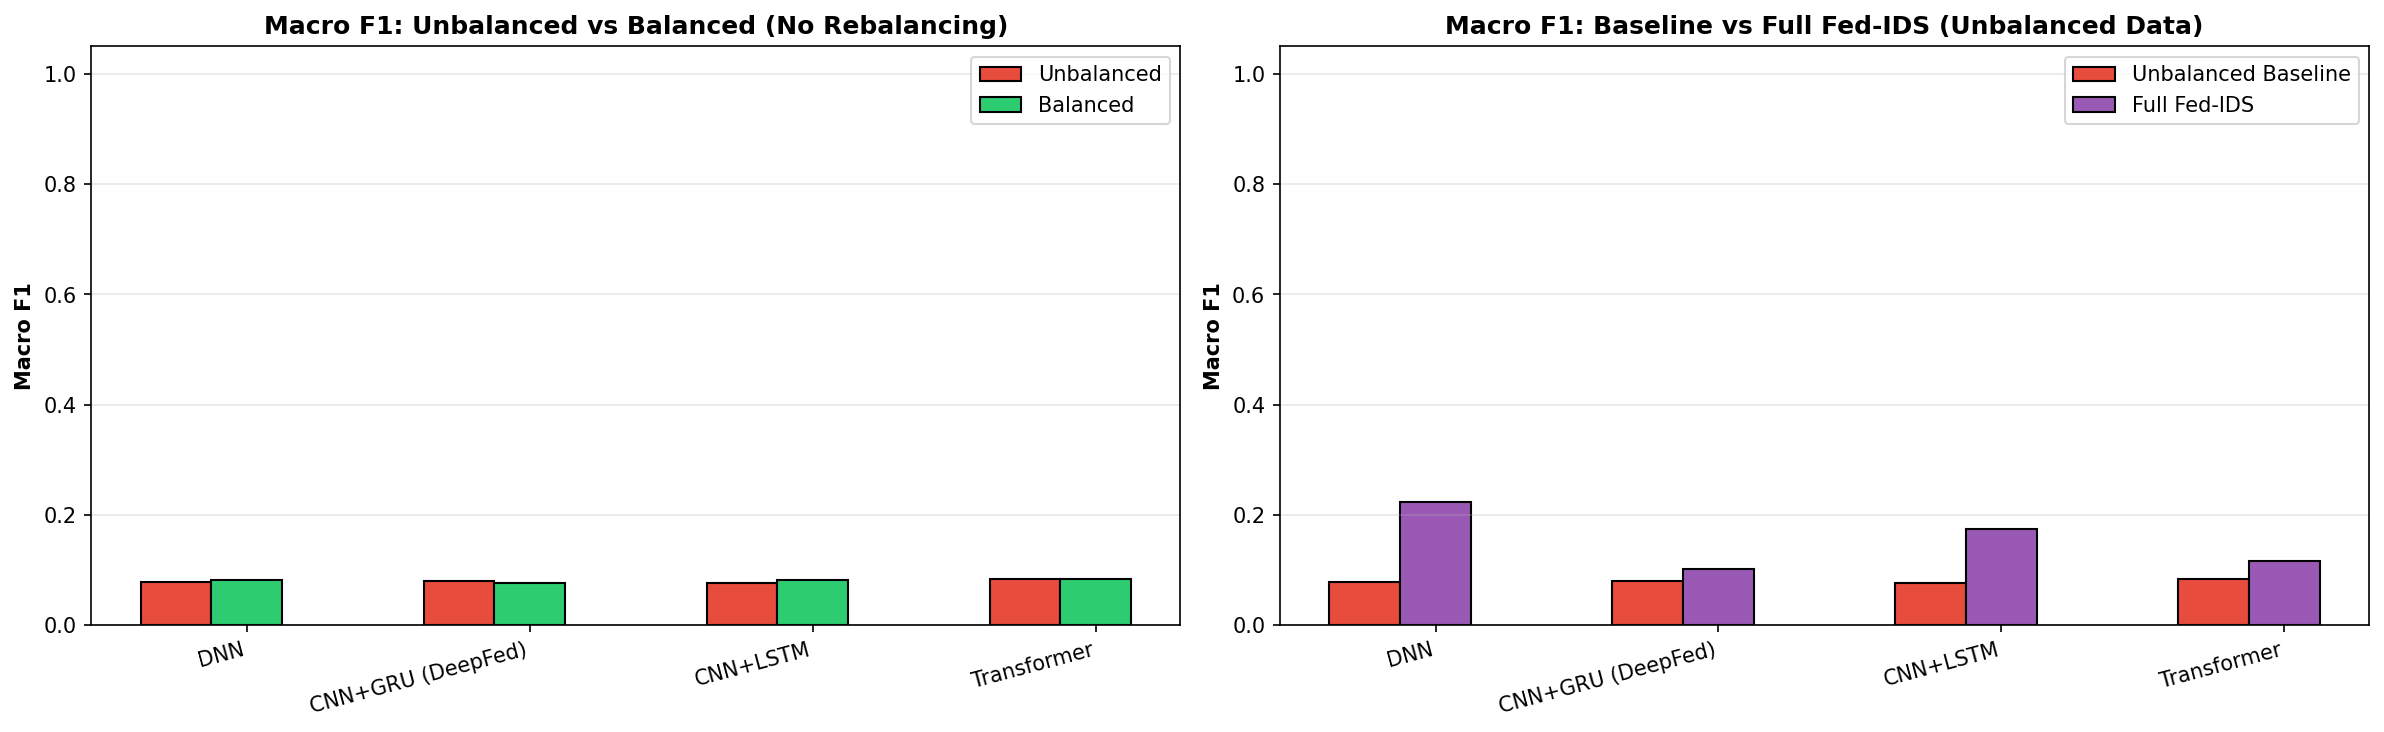

## 📉 Per-Round Trends

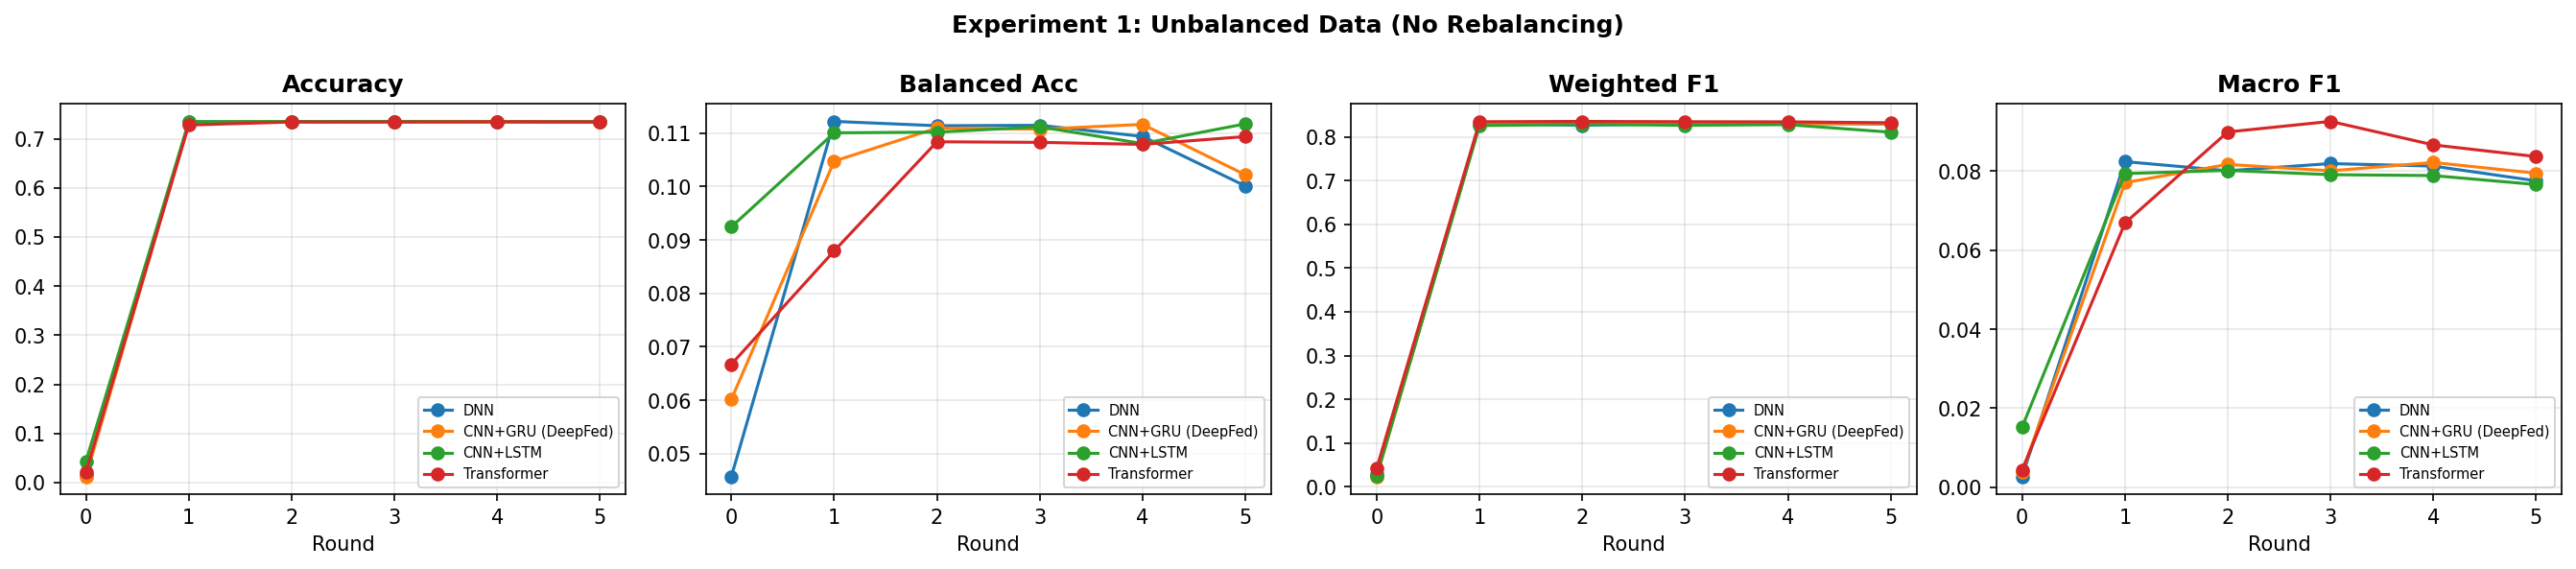
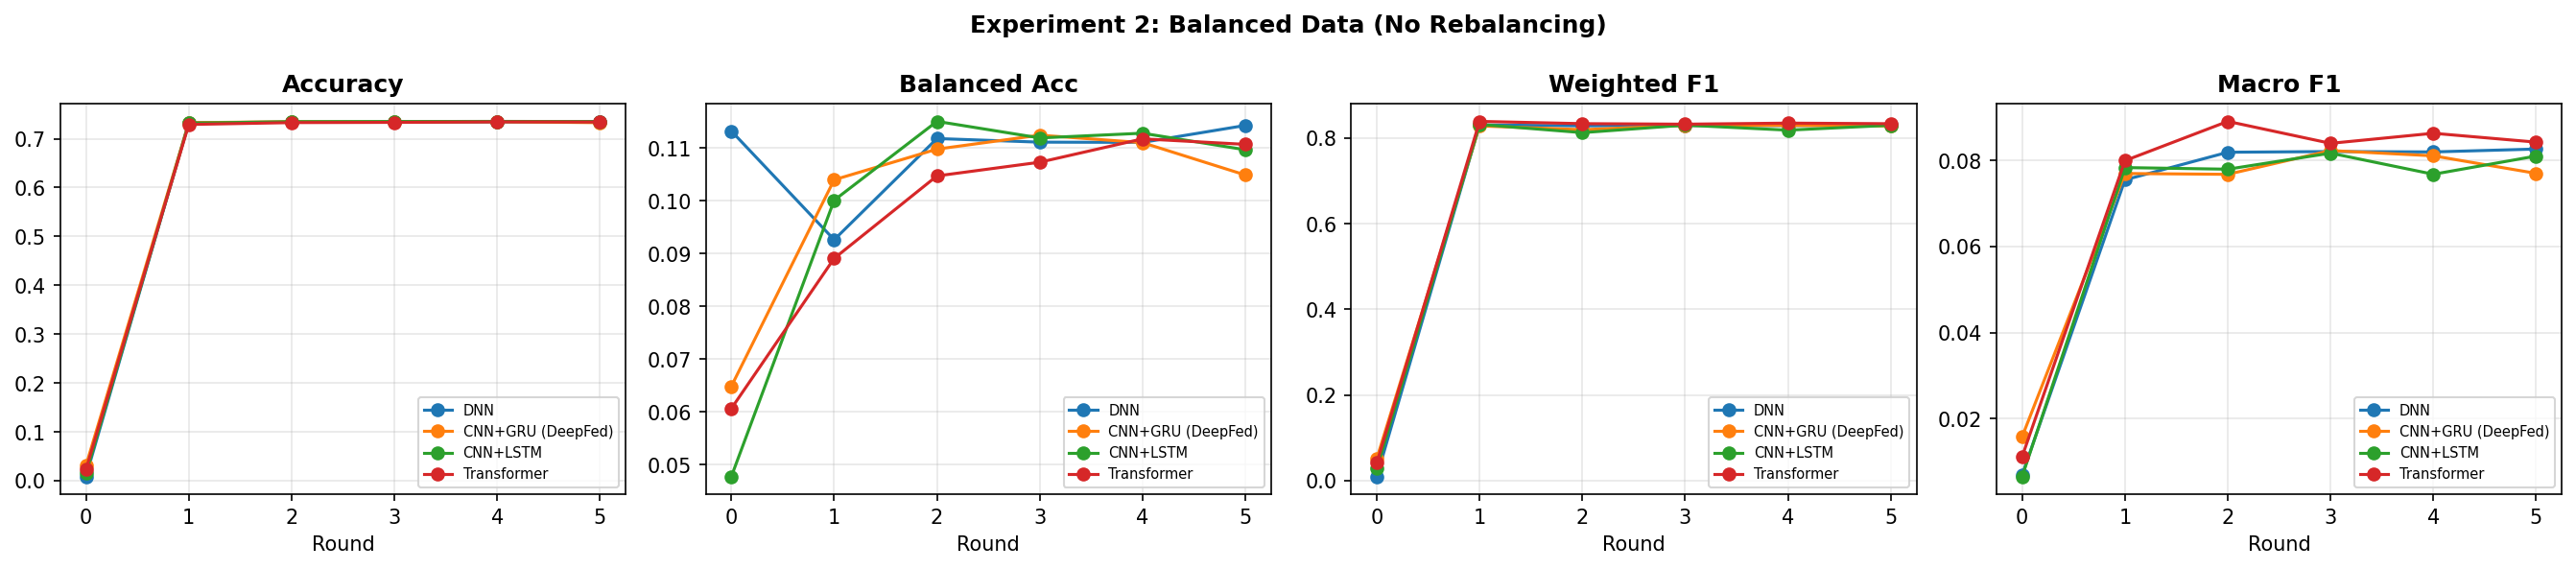
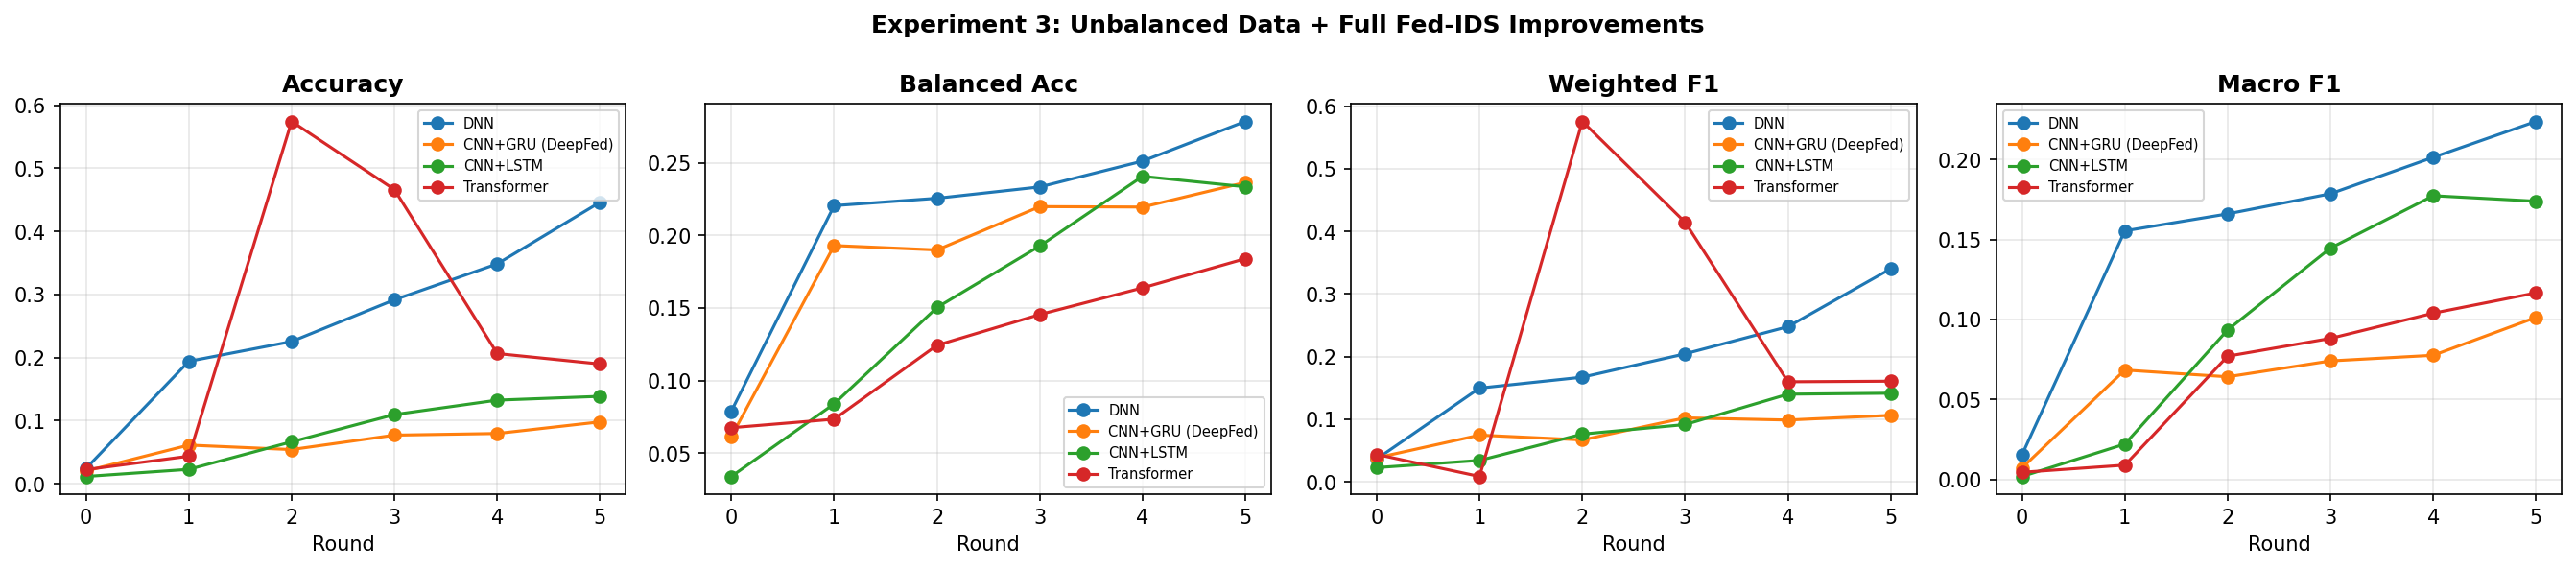

## 📝 Notes

- GPU: all model training and evaluation runs on the NVIDIA GPU via JAX/Keras.
- Full Fed-IDS includes: balanced local sampling, covariance-based feature-space augmentation, knowledge distillation from the server model, and smooth regularisation.


In [ ]:
#@title End { display-mode: "form" }
print("Notebook complete.")